In [50]:
import numpy as np
import pandas as pd
import joblib

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# modeling and metrics
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

RANDOM_STATE = 42

In [51]:
train_df = pd.read_parquet("../data/train_preprocessed.parquet")
test_df = pd.read_parquet("../data/test_preprocessed.parquet")

print("Train shape (1 year before test month):", train_df.shape)
print("Test shape  (test month):", test_df.shape)

Train shape (1 year before test month): (82459, 29)
Test shape  (test month): (7501, 29)


In [38]:
artifacts = joblib.load("../data/baseline_artifacts.joblib")
X_train, X_test = artifacts["X_train"], artifacts["X_test"]
y_train, y_test = artifacts["y_train"], artifacts["y_test"]
feature_names = artifacts["feature_names"]
linear_model = artifacts["linear_model"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (82459, 3446), X_test: (7501, 3446)


---
# Decision Tree and Random Forests Regressor

In [39]:
# model evaluator for efficiency
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "model": name,
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "test_rmse": root_mean_squared_error(y_test, test_pred),
        "test_mape": mean_absolute_percentage_error(y_test, test_pred),
    }

results = [evaluate_model(linear_model, X_train, y_train, X_test, y_test, "Linear Regression (baseline)")]

In [40]:
# DT should be overfit (to compare with other models later)
tree_unconstrained = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_unconstrained.fit(X_train, y_train)
results.append(evaluate_model(tree_unconstrained, X_train, y_train, X_test, y_test, "Decision Tree (unconstrained)"))

pd.DataFrame(results).round(4)

,model,train_r2,test_r2,test_mae,test_rmse,test_mape
0,Linear Regression (baseline),0.8395,0.8302,205714.4329,363642.6295,0.2054
1,Decision Tree (unconstrained),0.9994,0.7919,195164.6327,402582.7030,0.1550


In [41]:
# DT with constraints
tree_model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
results.append(evaluate_model(tree_model, X_train, y_train, X_test, y_test, "Decision Tree (max_depth=12, min_leaf=20)"))

pd.DataFrame(results).round(4)

,model,train_r2,test_r2,test_mae,test_rmse,test_mape
0,Linear Regression (baseline),0.8395,0.8302,205714.4329,363642.6295,0.2054
1,Decision Tree (unconstrained),0.9994,0.7919,195164.6327,402582.7030,0.1550
2,"Decision Tree (max_depth=12, min_leaf=20)",0.8305,0.7962,208043.5581,398428.2120,0.1718


In [ ]:
# RF
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)
results.append(evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest"))

comparison_df = pd.DataFrame(results).round(4)

---
# Model Comparisons

,model,train_r2,test_r2,test_mae,test_rmse,test_mape,train_test_gap
0,Linear Regression (baseline),0.8395,0.8302,205714.4329,363642.6295,0.2054,0.0093
1,Decision Tree (unconstrained),0.9994,0.7919,195164.6327,402582.7030,0.1550,0.2075
2,"Decision Tree (max_depth=12, min_leaf=20)",0.8305,0.7962,208043.5581,398428.2120,0.1718,0.0343
3,Random Forest,0.9326,0.8747,150692.2052,312482.4871,0.1211,0.0579


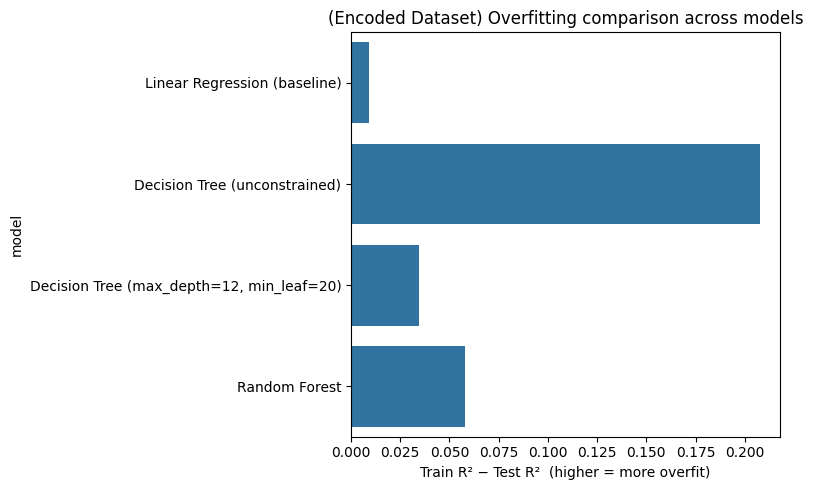

In [ ]:
comparison_df["train_test_gap"] = comparison_df["train_r2"] - comparison_df["test_r2"]
display(comparison_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comparison_df, y="model", x="train_test_gap", ax=ax)
ax.set_xlabel("Train R² - Test R²")
ax.set_title("Overfitting comparison across models")
plt.tight_layout()

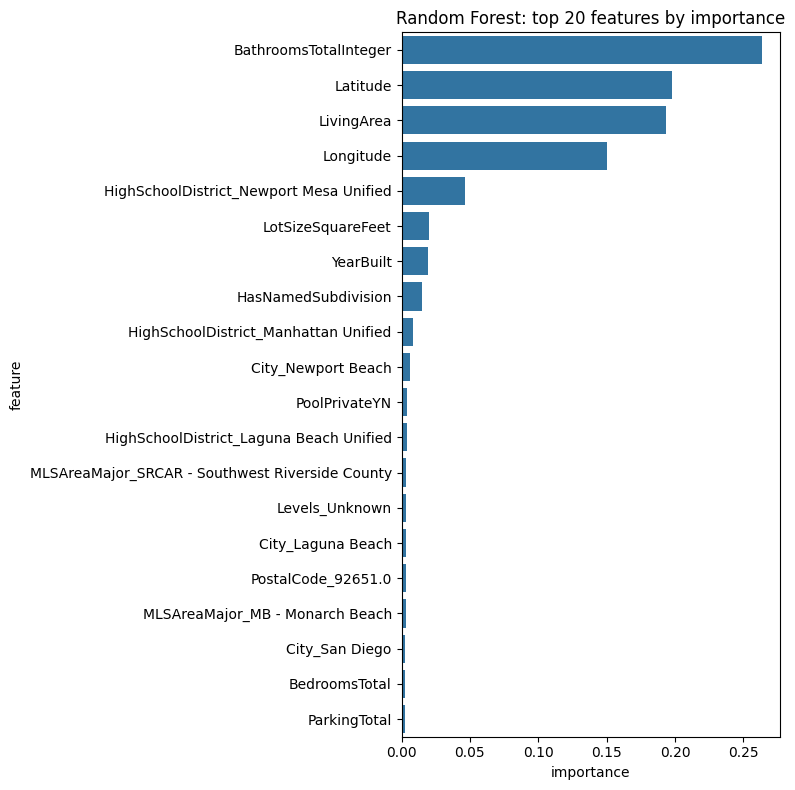

In [56]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=top20, y="feature", x="importance", ax=ax)
ax.set_title("Random Forest: top 20 features by importance")
plt.tight_layout()

# Summary

- Tested the DT and RF regressors with the subset of data containing only numerical variables, and those models performed nearly identically (0.01-0.0005 decrease in Rsquared potentially due to too many features)
- Categorical encoding matters enormously for linear models (increased Rsqaured by ~30%) and is nearly redundant for tree-based models (trees can already recover spatial structure from raw coordinates). In the feature importance plot, we see categorical geographic features are not as helpful as longitude and latitude.
- Believe that models like Catboost, LightGBM, and XGBoost will perform better

In [48]:
comparison_df

,model,train_r2,test_r2,test_mae,test_rmse,test_mape,train_test_gap
0,Linear Regression (baseline),0.8395,0.8302,205714.4329,363642.6295,0.2054,0.0093
1,Decision Tree (unconstrained),0.9994,0.7919,195164.6327,402582.7030,0.1550,0.2075
2,"Decision Tree (max_depth=12, min_leaf=20)",0.8305,0.7962,208043.5581,398428.2120,0.1718,0.0343
3,Random Forest,0.9326,0.8747,150692.2052,312482.4871,0.1211,0.0579
